In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings 
warnings.filterwarnings('ignore')

In [33]:
df=pd.read_csv('data/stud.csv')

In [34]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [35]:
df.shape
 # Shape of Dataset

(1000, 8)

In [36]:
df.isna().sum() # Checking for Null Values

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

In [37]:
df.duplicated().sum() 


np.int64(0)

In [38]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

In [39]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


According to above we can say that mean is between 66 and 68.05
minimum math score is 0 and for writing minimum it is 10 and reading score is 17


In [40]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [41]:
print("Categories in 'gender' variable:",end=" ")
print(df['gender'].unique())

print("Categories in 'race_ethnicity' variable:",end=" ")
print(df['race_ethnicity'].unique())

print("Categories in 'parental_level_of_education' variable:",end=" ")
print(df['parental_level_of_education'].unique())

print("Categories in 'lunch	' variable:",end=" ")
print(df['lunch'].unique())

print("Categories in '	test_preparation_course' variable:",end=" ")
print(df['test_preparation_course'].unique())



Categories in 'gender' variable: <StringArray>
['female', 'male']
Length: 2, dtype: str
Categories in 'race_ethnicity' variable: <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
Categories in 'parental_level_of_education' variable: <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
Categories in 'lunch	' variable: <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
Categories in '	test_preparation_course' variable: <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [42]:
##Category data 
numeric_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object', 'category']).columns

print(f"We have {len(numeric_features)} numerical features: {list(numeric_features)}")
print(f"We have {len(categorical_features)} categorical features: {list(categorical_features)}")
##Handles:
#int64, float64 → numerical
#object, category → categorical

We have 3 numerical features: ['math_score', 'reading_score', 'writing_score']
We have 5 categorical features: ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


Total Score and Average Score Basically this will act as Output Feature

In [43]:
df['Total Score']= df['math_score']+df['reading_score']+df['writing_score']
df['Average']=df['Total Score']/3
df.head() 

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [44]:
reading_full=df[df['reading_score'] == 100]['Average'].count()
writing_full=df[df['writing_score'] == 100]['Average'].count()
math_full=df[df['math_score'] == 100]['Average'].count()
print(f"Number of students with a perfect reading score: {reading_full}")
print(f"Number of students with a perfect writing score: {writing_full}")
print(f"Number of students with a perfect math score: {math_full}")


Number of students with a perfect reading score: 17
Number of students with a perfect writing score: 14
Number of students with a perfect math score: 7


In [45]:
reading_less_20=df[df['reading_score'] < 20]['Average'].count()
writing_less_20=df[df['writing_score'] < 20]['Average'].count()
math_less_20=df[df['math_score'] < 20]['Average'].count()
print(f"Number of students with a reading score less than 20: {reading_less_20}")
print(f"Number of students with a writing score less than 20: {writing_less_20}")
print(f"Number of students with a math score less than 20: {math_less_20}")

Number of students with a reading score less than 20: 1
Number of students with a writing score less than 20: 3
Number of students with a math score less than 20: 4


INSIGHTS
1. From above values we get students have perfomed the worst in maths
2. best perfomance in reading section 

DATA VISUALIZATION




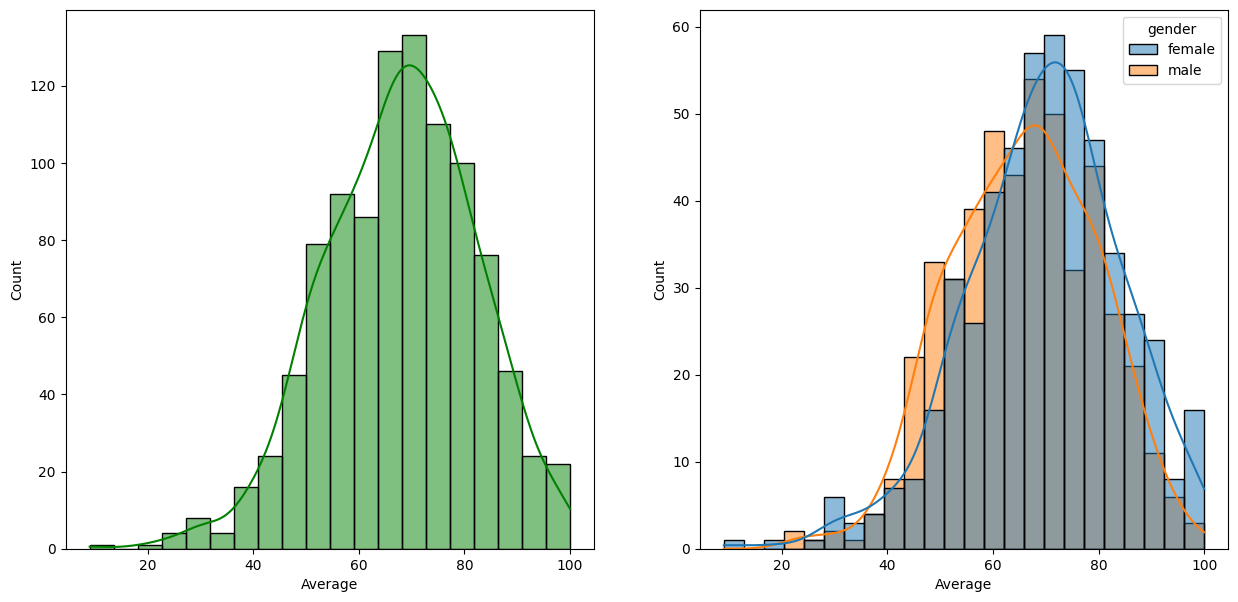

In [46]:
fig,axs=plt.subplots(1,2,figsize=(15,7))
plt.subplot(121)
sns.histplot(data=df,x='Average',bins=20,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='Average',kde=True,hue='gender')
plt.show()



We can see female perform better
Similarly we can do for total score

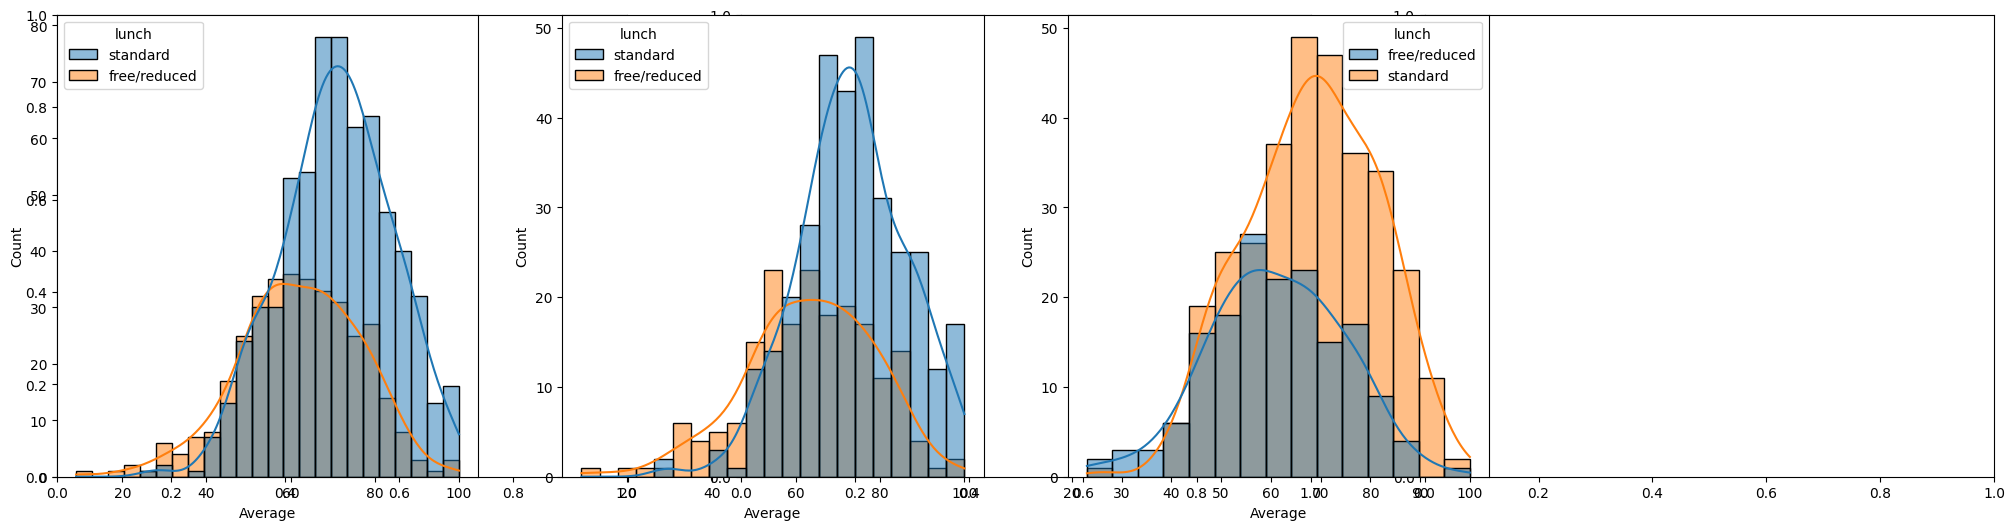

In [47]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df,x='Average',kde=True,hue='lunch')
plt.subplot(142)
sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='lunch')
plt.subplot(143)
sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='lunch')
plt.show()

#####  Insights
- Standard lunch helps perform well in exams.
- Standard lunch helps perform well in exams be it a male or a female.


In [48]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


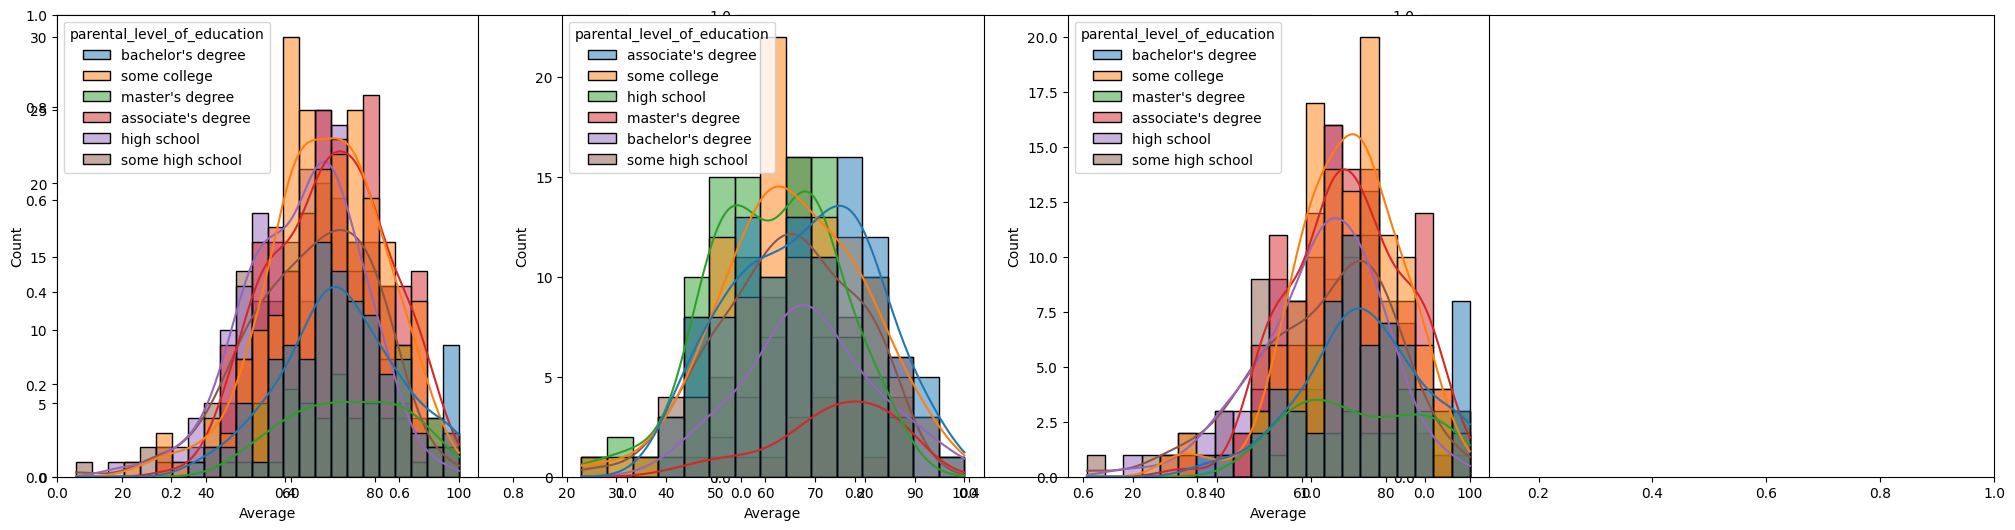

In [24]:
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
ax =sns.histplot(data=df,x='Average',kde=True,hue='parental_level_of_education')
plt.subplot(142)
ax =sns.histplot(data=df[df.gender=='male'],x='Average',kde=True,hue='parental_level_of_education')
plt.subplot(143)
ax =sns.histplot(data=df[df.gender=='female'],x='Average',kde=True,hue='parental_level_of_education')
plt.show()

#####  Insights
- In general parent's education don't help student perform well in exam.
- 2nd plot shows that parent's whose education is of associate's degree or master's degree their male child tend to perform well in exam
- 3rd plot we can see there is no effect of parent's education on female students.

INSIGHTS 
- Students of group A and group B tends to perform poorly in exam.
- Students of group A and group B tends to perform poorly in exam irrespective of whether they are male or female

- From the above three plots its clearly visible that most of the students score in between 60-80 in Maths whereas in reading and writing most of them score from 50-80

- Number of Male and Female students is almost equal
- Number students are greatest in Group C
- Number of students who have standard lunch are greater
- Number of students who have not enrolled in any test preparation course is greater
- Number of students whose parental education is "Some College" is greater followed closely by "Associate's Degree"

#### BIVARIATE ANALYSIS ( Is gender has any impact on student's performance ? ) 

In [49]:
gender_group = df.groupby('gender').mean(numeric_only=True)
gender_group

,math_score,reading_score,writing_score,Total Score,Average
gender,,,,,
female,63.633205,72.608108,72.467181,208.708494,69.569498
male,68.728216,65.473029,63.311203,197.512448,65.837483


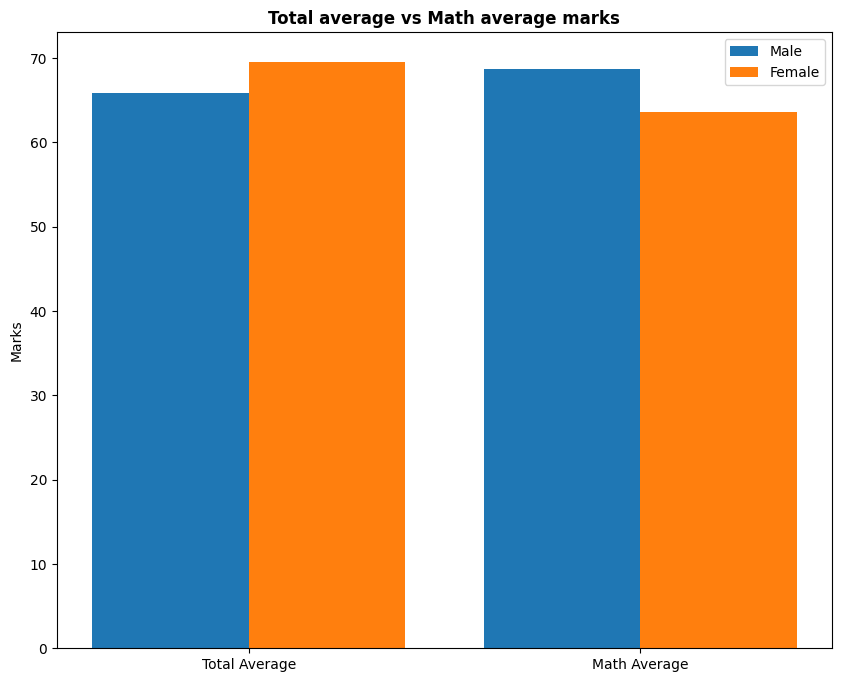

In [50]:
# Create average
df['Average'] = df[['math_score','reading_score','writing_score']].mean(axis=1)

# Group
gender_group = df.groupby('gender').mean(numeric_only=True)

# Data
X = ['Total Average', 'Math Average']

female_scores = [
    gender_group.loc['female', 'Average'],
    gender_group.loc['female', 'math_score']
]

male_scores = [
    gender_group.loc['male', 'Average'],
    gender_group.loc['male', 'math_score']
]

# Plot
X_axis = np.arange(len(X))

plt.figure(figsize=(10,8))
plt.bar(X_axis - 0.2, male_scores, 0.4, label='Male')
plt.bar(X_axis + 0.2, female_scores, 0.4, label='Female')

plt.xticks(X_axis, X)
plt.ylabel("Marks")
plt.title("Total average vs Math average marks", fontweight='bold')
plt.legend()
plt.show()

#### Insights 
- On an average females have a better overall score than men.
- whereas males have scored higher in Maths.

#### 4.4.2 RACE/EHNICITY COLUMN
- How is Group wise distribution ?
- Is Race/Ehnicity has any impact on student's performance ?

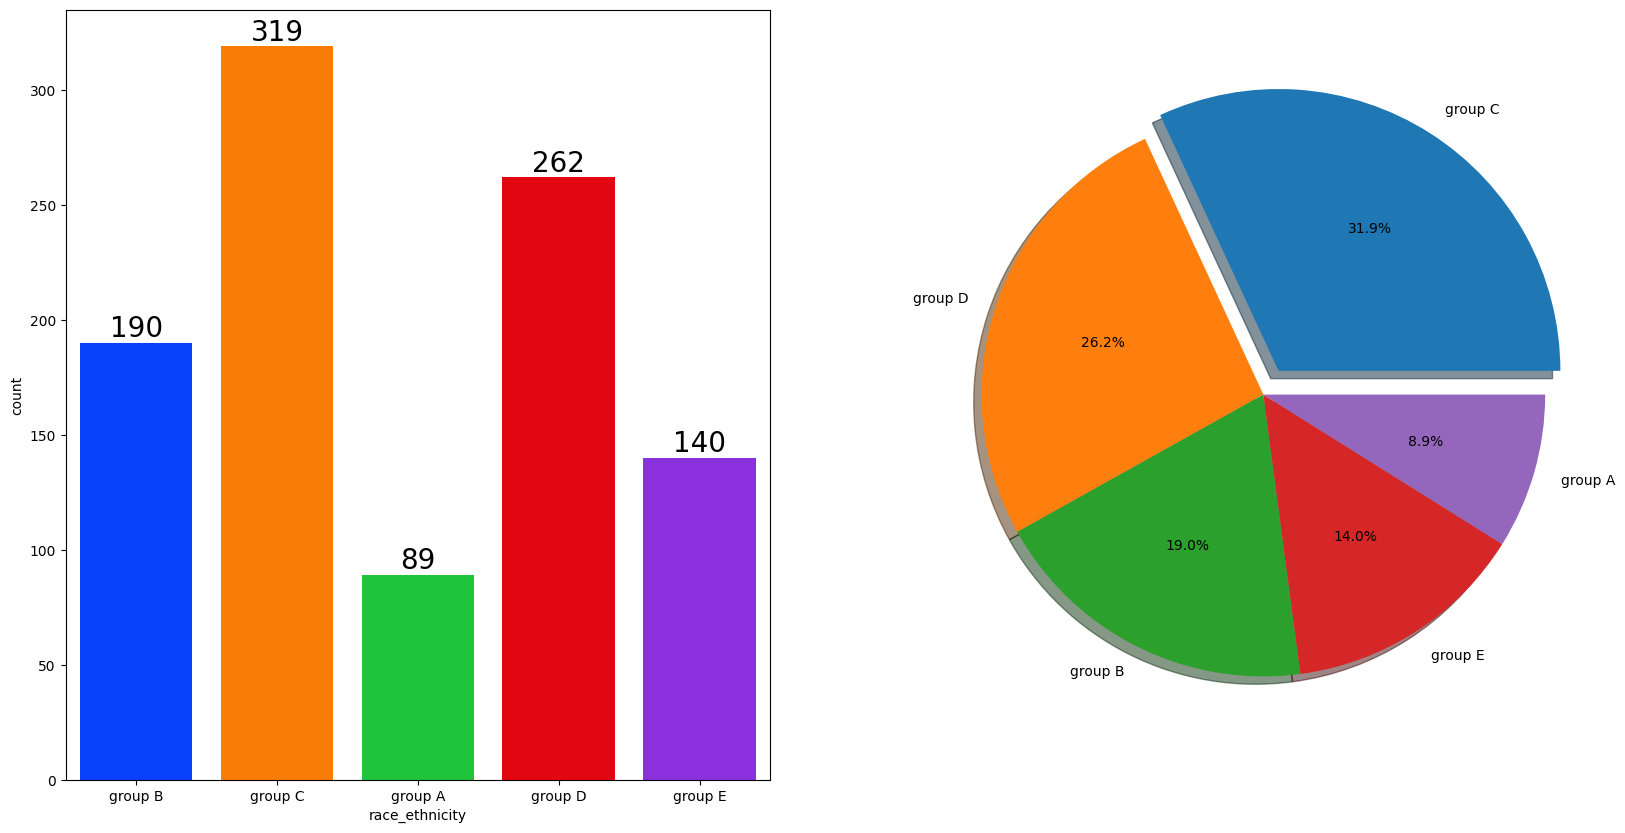

In [51]:
f,ax=plt.subplots(1,2,figsize=(20,10))
sns.countplot(x=df['race_ethnicity'],data=df,palette = 'bright',ax=ax[0],saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x = df['race_ethnicity'].value_counts(),labels=df['race_ethnicity'].value_counts().index,explode=[0.1,0,0,0,0],autopct='%1.1f%%',shadow=True)
plt.show()   

#### Insights 
- Most of the student belonging from group C /group D.
- Lowest number of students belong to groupA.

#### BIVARIATE ANALYSIS ( Is Race/Ehnicity has any impact on student's performance ? )

Similarly we can for following
- is parental education has any impact on student performance
- which type of luch is common in students
- does lunch effect student test marks?


### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.